### This notebook summarize the date-randomization test performed on satRNA dataset

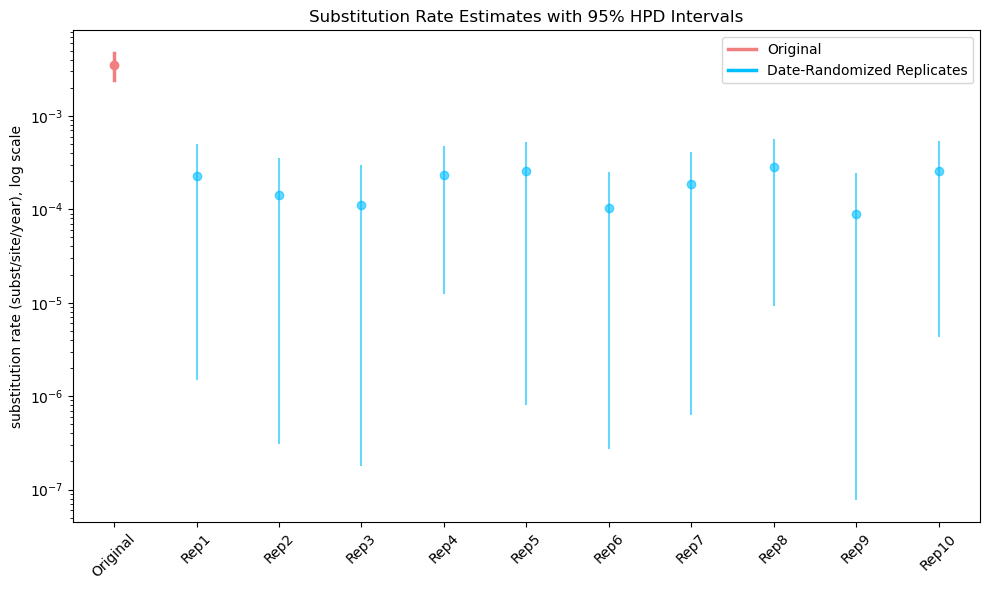

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Inferred substitution rates with 95% HPD intervals from BEAST analysis for the original and 10 date-randomized replicates
data = {
    "run": ["Original", "Rep1", "Rep2", "Rep3", "Rep4", "Rep5", "Rep6", "Rep7", "Rep8", "Rep9", "Rep10"],
    "Mean": [3.51E-03, 2.30E-04, 1.42E-04, 1.11E-04, 2.32E-04, 2.55E-04, 1.04E-04, 1.86E-04, 2.82E-04, 8.92E-05, 2.59E-04],
    "Lower": [2.42E-03, 1.53E-06, 3.13E-07, 1.85E-07, 1.26E-05, 8.19E-07, 2.78E-07, 6.44E-07, 9.55E-06, 7.83E-08, 4.44E-06],
    "Higher": [4.75E-03, 4.88E-04, 3.42E-04, 2.92E-04, 4.67E-04, 5.19E-04, 2.45E-04, 4.03E-04, 5.55E-04, 2.38E-04, 5.31E-04],
}

df = pd.DataFrame(data)
df["Index"] = range(len(df)) 

plt.figure(figsize=(10, 6))

for i, row in df.iterrows():
    if row["run"] == "Original":
        plt.plot([row["Index"], row["Index"]], [row["Lower"], row["Higher"]], color="lightcoral", linewidth=2.5)
        plt.scatter(row["Index"], row["Mean"], color="lightcoral", label="Original" if i == 0 else "")
    else:
        plt.plot([row["Index"], row["Index"]], [row["Lower"], row["Higher"]], color="deepskyblue", alpha=0.6)
        plt.scatter(row["Index"], row["Mean"], color="deepskyblue", alpha=0.6)


from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='lightcoral', lw=2.5, label='Original'),
    Line2D([0], [0], color='deepskyblue', lw=2.5, label='Date-Randomized Replicates')
]
plt.legend(handles=custom_lines)

plt.xticks(df["Index"], df["run"], rotation=45)
plt.yscale("log")
plt.ylabel("substitution rate (subst/site/year), log scale")
plt.title("Substitution Rate Estimates with 95% HPD Intervals")
plt.tight_layout()
plt.show()